> Wer mit anderen teilt, isst doppelt gut.

___

In dieser Kurseinheit werden wir uns mit der Parallelverarbeitung mit Spark beschäftigen. 

**_Bitte beachten:_**

- In Raw-Zellen erwarten wir Antworten im Freitext-Format. In Code-Zellen soll Code eingefügt werden, bei Bedarf mit Kommentaren. Weitere Formate werden mit Markdown bearbeitet
- Fragestellungen sind teilweise bewusst etwas offener formuliert, weil Sie auch im Arbeitsleben nur selten mit ganz spezifischen Anweisungen rechnen können. Es gibt häufig mehrere mögliche Lösungen, dies wird in der Korrektur berücksichtigt.

**_Zur Arbeit mit Spark:_**

* _Shuffling ist eine teure Operation_, die Festplatten-I/O, Serialisierung und Deserialisierung von Daten sowie Netzwerk-I/O umfasst. Obwohl Shuffle-Operationen nicht vollständig vermieden werden können, sollte versucht werden, ihre Anzahl zu reduzieren, indem unnötige Operationen eliminiert werden.

* Bei der Arbeit mit DataFrames _sollten UDFs unbedingt vermieden_ werden. Setzen Sie sie nur ein, wenn die integrierten Spark-Funktionen nicht ausreichen. UDFs sind eine Blackbox für Spark und können daher nicht optimiert werden, wodurch alle Optimierungen, die Spark für DataFrames/Datasets vornimmt, verloren gehen. Wann immer möglich, sollten die _integrierten SQL-Funktionen von Spark verwendet_ werden, da diese Optimierungsmöglichkeiten bieten.

* Bei der Arbeit mit Spark _sollten alle Daten in Spark-Strukturen verwendet werden_, anstatt for-Schleifen zu nutzen. Durch die Lazy Evaluation werden Transformationen in einer for-Schleife nicht sofort ausgeführt, sondern alle Aufrufe werden gesammelt und erst ausgeführt, wenn eine Action erfolgt. Dadurch entstehen viele parallele Aufgaben. Wenn stattdessen Spark-Strukturen verwendet werden, kann Spark diese intern optimieren und besser mit der Ressourcenverwaltung und den anderen Funktionen des Frameworks zusammenarbeiten. Dies kann zunächst ungewohnt erscheinen, besonders aus einer objektorientierten Perspektive, da die Strukturen redundant wirken.
___

Ziel ist es, die Zugänglichkeit von Lebensmitteln und Trinkwasser für die Bevölkerung in Deutschland zu analysieren.
Refill-Deutschland und Mundraub sind Plattformen, die die Standorte von Früchten, Pflanzen und Zapfstellen in Deutschland erfassen. Beide Datensätze stammen aus <a href="https://www.govdata.de/">GovData</a> und beinhalten geographische Punkte, an denen es freien Zugang zu Wasser und Lebensmittel gibt. 
In diesem Arbeitsblatt beschäftigen wir uns ausschließlich mit dem Datensatz Mundraub.

Die Verwendung externer Quellen und das Einfügen von Anmerkungen am Ende des Protokolls ist weiterhin erlaubt! :)

In [ ]:
# Imports
from pyspark.sql import SparkSession
import pyspark.sql.functions as f

Den Eintrittspunkt in die Funktionalität von Spark ist der **_SparkContext_**, der auch die Verbindung zu den Exekutoren darstellt. Bei seiner Erstellung werden zudem verschiedene Konfigurationsparameter übergeben.  Zu Beginn konzentrieren wir uns auf die Angabe des Masters und des App-Namens:
- **master:** Wir verwenden YARN als Ressourcen-Manager und starten die Anwendung im Client-Modus.
- **appName:** Hier vergeben wir einen Namen für unsere Applikation.

Da wir später mit SparkSQL arbeiten möchten, erstellen wir zunächst eine **_SparkSession_**. Diese dient als Einstiegspunkt für die SparkSQL-Funktionalität und enthält auch den SparkContext.

In [ ]:
# SparkSession erstellen
spark = SparkSession.builder \
                    .master("yarn") \
                    .appName("KE5") \
                    .getOrCreate()
# SparkContext
sc = spark.sparkContext

# RDDs (Resilient Distributed Datasets)
RDDs bilden das Fundament von Spark und ermöglichen die verteilte, fehlertolerante Verwaltung und Verarbeitung von Daten über mehrere Knoten hinweg. Die folgenden Aufgaben sollen Ihnen helfen, den Umgang mit RDDs besser zu verstehen, da eine falsche Nutzung zu Performance-Problemen führen kann.

In der Praxis arbeitet man meist nicht direkt mit RDDs, sondern verwendet High-Level-Bibliotheken wie SparkSQL oder die DataFrame-API. Dennoch ist es wichtig, die Konzepte der RDDs zu verstehen, da sie die Grundlage von Spark bilden.

Im Folgenden widmen wir uns den wichtigsten Eigenschaften von RDDs:
- In-Memory-Verarbeitung
- Lazy
- Partitioniert
- Unveränderlich
- Lineage

## In-Memory: Thinking hard... to remember something
Wieso verwendet Spark die "In-Memory-Verarbeitung"? (Nennen Sie bitte mind. 2 Vorteile).

Wann könnte die In-Memory-Verarbeitung an ihren Grenzen stoßen?

## Lazy: Transform today and act tomorrow?
Erklären Sie, was es für die Programmierung bedeutet, dass die Verarbeitung in Spark _lazy_ ausgeführt wird.

## Partitioned: Divide and conquer
Erstellen Sie aus der vorgegebenen Liste (`data`) ein RDD namens `rdd_part` mit drei Partitionen. Kontrollieren Sie nach der Erstellung, dass die korrekte Anzahl Partitionen erzeugt wurde.

In [ ]:
data = [1 for i in range (10)] + [0 for i in range (5)]

In [ ]:
# Ihre Lösung

Im Folgenden schauen wir uns die Verteilung der Daten auf die unterschiedlichen Partitionen an.

> ⚠️ **Achtung:** Die Anwendung von `collect()` in Kombination mit `glom()` ist nur für kleine Datensätze geeignet!

In [ ]:
rdd_part.glom().collect()

Wie wir sehen können, bestehen zwei Partitionen aus 1en und eine aus 0en. Filtern Sie das RDD nun so, dass nur die Werte größer 0 übrig bleiben. Erstellen Sie hierfür ein neues RDD namens `rdd_filtered`.

In [ ]:
# Ihre Lösung

Wenn wir uns nun die Verteilung der Daten auf die Partitionen ansehen, sehen wir, dass wir eine leere Partition erzeugt haben:

In [ ]:
rdd_filtered.glom().collect()

Beschreiben Sie die Nachteile von leeren Partitionen. Wie kann dieses Problem gelöst werden (Stichwort *Shuffling*) und warum sollte Shuffling normalerweise vermieden werden?

## Immutable & Lineage: Wie Familie, nur für Daten
Warum sind RDDs unveränderlich und wie hängt jedes RDD mit seiner Abstammung (*Lineage*) zusammen? Welche Vorteile bringt diese Unveränderlichkeit?

## RDDs in Action
Laden Sie den Datensatz von Mundraub in ein RDD mit dem Namen `rdd_mundraub` und geben Sie dann die ersten 5 Zeilen aus. 
Verwenden Sie den Datensatz aus Moodle `mundraub_preprocessed.csv`. Dies ist derselbe Datensatz, der in KE4 verwendet wurde.

*Hinweis: Denken Sie daran, dass die Daten standardmäßig aus dem HDFS geladen werden. Aus diesem Grund müssen die Daten zunächst ins HDFS geladen werden. Verwenden Sie hierzu das Notebook hdfs-upload.ipynb, das wir Ihnen in Moodle zur Verfügung gestellt haben.*

In [ ]:
# Datensatz laden - rdd_mundraub

### Keep your head up!
Die erste Zeile entspricht dem Header. Entfernen Sie diese aus dem Datensatz. Geben Sie anschließend die Anzahl der Werte aus.

In [ ]:
# Ihre Lösung

### Kräuterpfad
In KE 4 haben wir bereits analysiert, welche Produkte typischerweise geerntet werden. Die gleiche Fragestellung möchten wir nun mit RDDs bearbeiten. Zählen Sie hierfür die Einträge pro `kind`. Ihr Ergebnis können Sie mit dem aus KE 4 vergleichen,

*Sollten Sie keinen Lösungsansatz haben, nutzen Sie den Schieberegler unten für weitere Hinweise*

- Aktuell ist jede Zeile des RDD ein String, in dem die einzelnen Felder durch Komma getrennt sind. Dieser String muss zunächst gesplittet werden.
- Im nächsten Schritt müssen Key-Value-Paare gebildet werden. Der Key ist das Produkt und der Wert ist 1.
- Dann müssen pro Key alle Werte addiert werden.

*Wenn Sie Probleme mit der konkreten Umsetzung der Aufgabe haben, nutzen Sie den Schieberegler unten für weitere Hinweise zur Programmierung.*

- Das Splitten der einzelnen Funktionen erfolgt mit `split(",")`.
- Das dritte Element (`line[3]`) entspricht dem Produkt.
- Mithilfe der Funktion `reduceByKey()` können die Werte pro Key addiert werden.

In [ ]:
# Ihre Lösung

Die Arbeit mit RDDs ist offensichtlich recht mühsam, weshalb in der Praxis häufig eine High-level API wie SparkSQL verwendet wird. Diese schauen wir uns im Folgenden an.

# Dataframes :: DataFrame API
*DataFrames sind die zentrale Abstraktion der SparkSQL-Bibiliothek. Die Bibliothek bietet zwei praktisch gleichwertige APIs, um mit DataFrames zu arbeiten: Die DataFrame API und die SQL API.*

Wir arbeiten zunächst mit der DataFrame API. Diese ist besonders effizient für komplexe, wiederholbare Datenoperationen. Sie ermöglicht eine Echtzeitverarbeitung und bietet ein hohes Maß an Optimierung (z.B. Partitionierung und In-Memory-Speicherung).

*Hinweis: Für die Bearbeitung der folgenden Aufaben ist es teilweise hilfreich, sich die <a href="https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/functions.html">pyspark.sql.functions</a> anzusehen. Diese sind bereits importiert und können mit `f.<function_name>` verwendet werden.*



## Daten laden
Laden Sie den Datensatz von Mundraub in ein DataFrame mit dem Namen `df_mundraub`. Die Spaltenbezeichnungen sollen dabei im Header stehen und nicht Teil der Daten sein. Nutzen Sie außerdem die automatische Schemaerkennung von Spark. Geben Sie dann die ersten 5 Zeilen aus. Verwenden Sie hier den Datensatz `mundraub_preprocessed.csv`.

In [ ]:
# Datensatz laden - df_mundraub

Lassen Sie sich das Schema ausgeben.

In [ ]:
# Ihre Lösung

Zählen Sie wiederum die Anzahl der Einträge.

In [ ]:
# Ihre Lösung

## Kräuterpfad
Wie wir gesehen haben, ist die Arbeit mit RDDs recht umständlich. Lösen Sie nun die Frage, welche Produkte am häufigsten geerntet werden, mit DataFrames, um die Komplexität zu vergleichen (zählen Sie also wiederum die Einträge pro `kind`).

In [ ]:
# Ihre Lösung

## Let's go nuts!
Im Folgenden haben wir ein Dictionary erstellt, das die verschiedenen Ernteprodukte in Kategorien einordnet.

In [ ]:
harvestClass = {
"Fruit Trees":{ "Apfel", "Kirsche", "Quitte", "Aprikose", "Pflaume",
    "Mirabelle", "Birne", "Maulbeere", "Felsenbirne",
    "Kornelkirsche", "Andere Obstbäume" },
"Bushes":{ "Brombeere", "Holunder", "Schlehe", "Johannisbeere",
    "Himbeere", "Heidelbeere", "Walderdbeere", "Sanddorn",
    "Weißdorn", "Hagebutte", "Andere Obststräucher" },
"Nuts":{ "Haselnuss", "Walnuss", "Esskastanie", "Andere Nüsse" },
"Herbs":{ "Bärlauch", "Rosmarin", "Minze", "Waldmeister", "Thymian", "Andere Kräuter" }
}

Verwenden Sie dieses Dictionary, um jene Daten zu finden, die Nüsse (`Nuts`) oder Kräuter (`Herbs`) enthalten. Gruppieren Sie diese Daten wiederum nach Produkt (`kind`) und zählen Sie, in wie vielen unterschiedlichen Städten (`city`) das jeweilige Produkt gefunden werden kann.

In [ ]:
# Ihre Lösung

In wie vielen verschiedenen Städten können Haselnüsse geerntet werden? Schreiben Sie Ihre Antwort in die untenstehende Raw-Zelle.

## Datenjagd 2023!
Im Folgenden betrachten wir nur die Haselnüsse. Wir möchten in einer Tabelle die Stadt und den Monat der Stationen sehen, bei denen Haselnüsse gefunden werden können und die seit 2023 erfasst wurden. Lassen Sie sich zur Kontrolle außerdem auch das Produkt (`kind`) in dieser Tabelle ausgeben.

In [ ]:
comparisonDate = "2023-01-01"

In [ ]:
# Ihre Lösung

## What should I take?
DataFrames basieren auf RDDs. Deshalb kann auch jedes DataFrame in ein RDD umgewandelt werden.
Führen Sie die folgenden beiden Zellen aus.

In [ ]:
df_mundraub.rdd.take(42)[41]["kind"]

In [ ]:
df_mundraub.take(42)[41]["kind"]

Beide Methoden scheinen zum gleichen Ergebnis zu führen. Was wird hier ausgegeben und worin liegen die Unterschiede zwischen den beiden Verfahren?

## Do you cache it, or catch it?
Durch die In-Memory-Verarbeitung werden DataFrames in der Regel nicht zwischengespeichert.
Mit jeder Action werden alle Verarbeitungsschritte neu ausgeführt. Manchmal kann es aber sinnvoll sein, ein DataFrame zwischenzuspeichern (zu cachen). Beim Aufruf der ersten Action wird das DataFrame dann im Speicher gehalten.

Betrachten Sie den folgenden Code: An welcher Stelle im Code wäre es sinnvoll, Caching zu verwenden, und warum? Fügen Sie den entsprechenden Code für das Caching hinzu und kommentieren Sie es mit 'CATCH'.

```bash
df1 = spark.read.csv(path = "my_big_data.csv", header = True)
df2 = df1.filter(df1.salary.between(40000, 50000))
df3 = df2.select("name", "salary", "department", "satisfied")
df4 = df3.groupby("department").agg({"satisfied": "mean"})
df4.show()
df5 = df3.groupby("department").agg({"salary": "mean"})
df5.show()
df6 = df3.select("name").where(df3["satisfied"] == 1)
df6.show()
```

Warum haben Sie an dieser Stelle Caching verwendet? Erklären Sie, welche DataFrames auf die gecachte Version zugreifen.

# Dataframes :: SQL API
Hier arbeiten wir mit der SQL API von Spark. Diese bietet einfache, strukturierte Abfragen in SQL-Form und ist mit externen Tools und Datenbenken kompatibel. Somit ist sie besonders geeignet für Benutzer, die vertraut im Umgang mit SQL sind.

## Kräuterpfad
Ermitteln Sie erneut, welche Produkte typischerweise geerntet werden, indem Sie die Einträge pro `kind` zählen. Verwenden Sie hierfür diesmal die SQL API.

Legen Sie zunächst eine temporäre View mit dem Namen `mundraubView` an. Achten Sie beim Laden der Datei darauf, dass der Header berücksichtigt wird, das Schema automatisch erkannt wird und einfache Anführungszeichen verwendet werden.

In [ ]:
# Ihre Lösung

Zählen Sie nun die Einträge pro `kind`.

In [ ]:
# Ihre Lösung

# Ressourcenverbrauch
In den folgenden Aufgaben werden wir uns mit dem Ressourcenverbrauch beschäftigen. Ziel ist es, verschiedene Situationen zu analysieren, in denen die Konfiguration des Clusters eine Rolle spielt. In diesen Übungen arbeiten Sie mit Ihrem eigenen Cluster. In der Praxis ist dies jedoch selten der Fall, da häufig viele Jobs gleichzeitig ausgeführt werden und um die Ressourcen konkurrieren.


    
*Hinweis: In dieser Aufgabe müssen Sie teilweise mit einem Terminal innerhalb des Containers arbeiten. Geben Sie dazu entweder den Befehl `docker exec -it dbis-pyspark-client-node bash` auf Ihrem Host-Terminal ein oder erstellen Sie dieses über die Startseite des Jupyter Notebooks mittels _New_ -> _Terminal_.*

<div class="alert alert-block alert-warning">

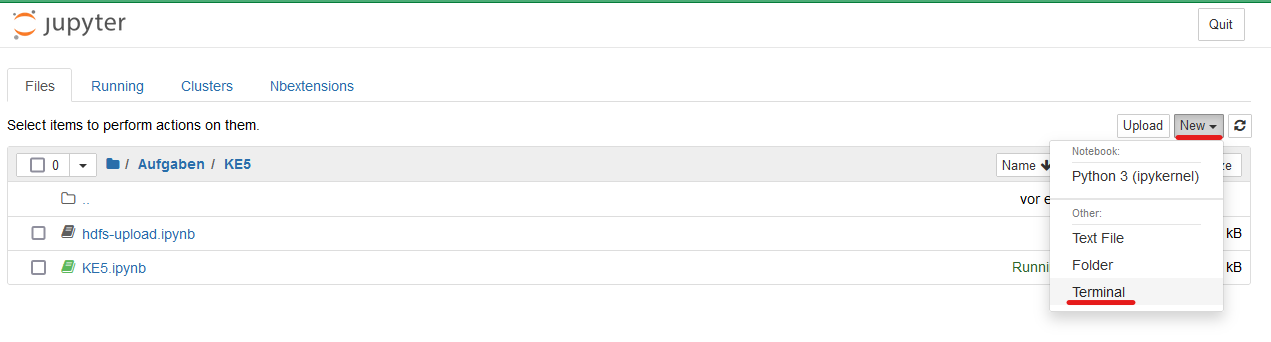
    
</div>

Öffnen Sie die __[WebUI von YARN](http://127.0.0.1:8088)__ und sehen sich die aktuellen Applikationen an. Sie sollten dort das aktuelle Jupyter Notebook finden. Solange die SparkSession (der SparkContext) erstellt ist, wird das Notebook dort als *RUNNING* aufgelistet. 

Die zugewiesenen Ressourcen können in der Datei `spark-defaults.conf` im Verzeichnis `SPARK_CONF_DIR` eingesehen werden.

Falls Sie nicht wissen, wie Sie die Datei finden können, nutzen Sie den Schieberegler unten für weitere Hinweise:

- Zugriff auf den Inhalt einer Umgebungsvariable mittels `$`, z.B. `$SPARK_CONF_DIR`
- Anzeige des Dateiinhalts mit dem Befehl `cat`

In [ ]:
%%bash
# Inhalt von spark-defaults.conf anzeigen lassen
cat $SPARK_CONF_DIR/spark-defaults.conf 

## Just some easy math
Wie viele Kerne und wie viel Speicher sind den Spark-Applikationen zugewiesen? Wie können Sie diese berechnen?

In [ ]:
Kerne:

Speicher:

Stoppen Sie den SparkContext, um alle Ressourcen, die dieses Notebook benötigt, freizugeben

In [ ]:
# Ihre Lösung

## Lola rennt
Starten Sie nun ein PySpark-Shell, mit YARN als Ressourcen-Manager im Client-Modus. Die Applikation soll außerdem zwei Executoren verwenden, von denen jeder über 1 GB Speicher und 2 Kerne verfügt.

Wie viele Kerne und wie viel Speicher verbraucht diese Spark-Applikation?

## Rennt Lola! rennt
Lassen Sie die erste Shell laufen und starten Sie nun eine zweite PySpark-Shell mit YARN als Ressourcen-Manager im Client-Modus mit derselben Konfiguration (zwei Executoren, jeweils mit 1 GB Speicher und 2 Kernen). Erstellen Sie ein RDD Ihrer Wahl und führen Sie ein collect aus.

Was passiert? Wie kann man das Problem lösen?

## Two and a Half Cores 
Beenden Sie nun beide Shells. Starten Sie anschließend eine neue PySpark-Shell mit YARN als Ressourcen-Manager im Client-Modus, mit 2 Kernen für den Application Master und 2 Executoren, jeweils mit 2 GB Speicher und 3 Kernen.

*Hinweis: Wenn Sie nicht sicher sind, wie Sie die Ressourcen für den Application Master zuweisen, verwenden Sie den Schieberegler unten.*

Option für Cores Application Master: `--conf spark.yarn.am.cores=2`

Wie sind die Ressourcen verteilt?

Welche Implikationen ergeben sich daraus? Kann ein `collect()` ausgeführt werden?

## Challenge Accepted!
Ohne die Pyspark-Shell aus der vorherigen Aufgabe zu beenden, starten Sie nun in einem zweiten Terminal eine PySpark-Shell mit dem folgenden Befehl gestartet:
```bash
pyspark --master yarn --conf spark.yarn.am.cores=3
```
Was passiert und warum? Überprüfen Sie auch den Status in der WebUI, die Applikation sollte dort als `ACCEPTED` angezeigt werden. Wie können Sie den Status auf `RUNNING` ändern?

# Notizen
Persönliche Notizen ;)